In [39]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_parquet('GlobalGeoTree-6M/GlobalGeoTreeNoMissing.parquet')
#df = df.sample(1000000)

In [40]:
# Create a reproducible train/test split and save to disk (parquet)
# Using pandas.sample to avoid adding scikit-learn dependency.
# Set test_frac to your desired test set proportion.

test_frac = 0.2

# For large DataFrames this will still operate in memory; if memory is constrained,
# consider streaming or writing indices and filtering on disk.
train_df = df.sample(frac=1 - test_frac, random_state=42)
test_df = df.drop(train_df.index)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# File paths to save
train_path = 'GlobalGeoTree-6M/train.parquet'
test_path = 'GlobalGeoTree-6M/test.parquet'

# Save (use pyarrow engine if available for speed)
train_df.to_parquet(train_path, index=False)
test_df.to_parquet(test_path, index=False)

print(f"Saved train to {train_path}, test to {test_path}")

Train shape: (4473286, 32)
Test shape: (1118322, 32)
Saved train to GlobalGeoTree-6M/train.parquet, test to GlobalGeoTree-6M/test.parquet
Saved train to GlobalGeoTree-6M/train.parquet, test to GlobalGeoTree-6M/test.parquet


In [41]:
#device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#hyperparameters
input_size = 28
hidden_size = 20
num_classes = 2725
num_epochs = 3
batch_size = 64
learning_rate=0.0005

#dataset
import numpy as np
from torch.utils.data import TensorDataset

# Prepare feature list and target (assume every feature is numeric except the target)
features = list(df)
undesirables = ['sample_id','level0','level1_family','level2_genus','level3_species']
target = 'level1_family'
features = [e for e in features if e not in undesirables and e != target]

# Use existing train_df/test_df if present, otherwise create a split
if 'train_df' not in globals() or 'test_df' not in globals():
    train_df = df.sample(frac=0.8, random_state=42)
    test_df = df.drop(train_df.index)

# At this point we assume features are numeric. Keep only features that actually exist in the DataFrame
features = [c for c in features if c in train_df.columns]
print(f"Using {len(features)} features for model input")

# Numeric preprocessing: compute train means/stds, fillna and scale
if features:
    num_means = train_df[features].mean()
    num_stds = train_df[features].std().replace(0,1)
else:
    num_means = pd.Series(dtype=float)
    num_stds = pd.Series(dtype=float)

def preprocess_numeric(df_in):
    if not features:
        return np.zeros((len(df_in),0), dtype=np.float32)
    X = df_in[features].fillna(num_means).astype(np.float32)
    X = ((X - num_means) / num_stds).to_numpy(dtype=np.float32)
    return X

# Encode target using train categories to guarantee consistent mapping
train_target_cat = pd.Categorical(train_df[target])
target_categories = list(train_target_cat.categories)
target_map = {v:i for i,v in enumerate(target_categories)}
print(f"Target classes (train): {len(target_categories)}")

def encode_target(series):
    return series.map(target_map).fillna(-1).astype(np.int64).to_numpy()

# Build arrays for train and test
X_train = preprocess_numeric(train_df)
y_train = encode_target(train_df[target])
X_test = preprocess_numeric(test_df)
y_test = encode_target(test_df[target])


# Convert to torch tensors (may be large for full dataset)
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test)

# Create TensorDatasets and DataLoaders (same format as before)
train_tensor = TensorDataset(X_train_t, y_train_t)
test_tensor = TensorDataset(X_test_t, y_test_t)

train_loader = torch.utils.data.DataLoader(dataset=train_tensor, batch_size = batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_tensor, batch_size = batch_size, shuffle=False)

Using 27 features for model input
Target classes (train): 271
Target classes (train): 271


In [42]:
examples = iter(train_loader)
samples, labels = next(examples)
print(samples.shape, labels.shape)

torch.Size([64, 27]) torch.Size([64])


epoch 1/3, step 64/69896, loss=5.4036
epoch 1/3, step 128/69896, loss=5.1466
epoch 1/3, step 192/69896, loss=4.9740
epoch 1/3, step 256/69896, loss=4.3560
epoch 1/3, step 320/69896, loss=4.1874
epoch 1/3, step 384/69896, loss=3.9614
epoch 1/3, step 448/69896, loss=3.9103
epoch 1/3, step 512/69896, loss=3.8864
epoch 1/3, step 320/69896, loss=4.1874
epoch 1/3, step 384/69896, loss=3.9614
epoch 1/3, step 448/69896, loss=3.9103
epoch 1/3, step 512/69896, loss=3.8864
epoch 1/3, step 576/69896, loss=3.9187
epoch 1/3, step 640/69896, loss=3.4242
epoch 1/3, step 704/69896, loss=3.5484
epoch 1/3, step 768/69896, loss=3.6626
epoch 1/3, step 576/69896, loss=3.9187
epoch 1/3, step 640/69896, loss=3.4242
epoch 1/3, step 704/69896, loss=3.5484
epoch 1/3, step 768/69896, loss=3.6626
epoch 1/3, step 832/69896, loss=3.6572
epoch 1/3, step 896/69896, loss=3.7840
epoch 1/3, step 960/69896, loss=3.6611
epoch 1/3, step 1024/69896, loss=3.4651
epoch 1/3, step 832/69896, loss=3.6572
epoch 1/3, step 896/69896

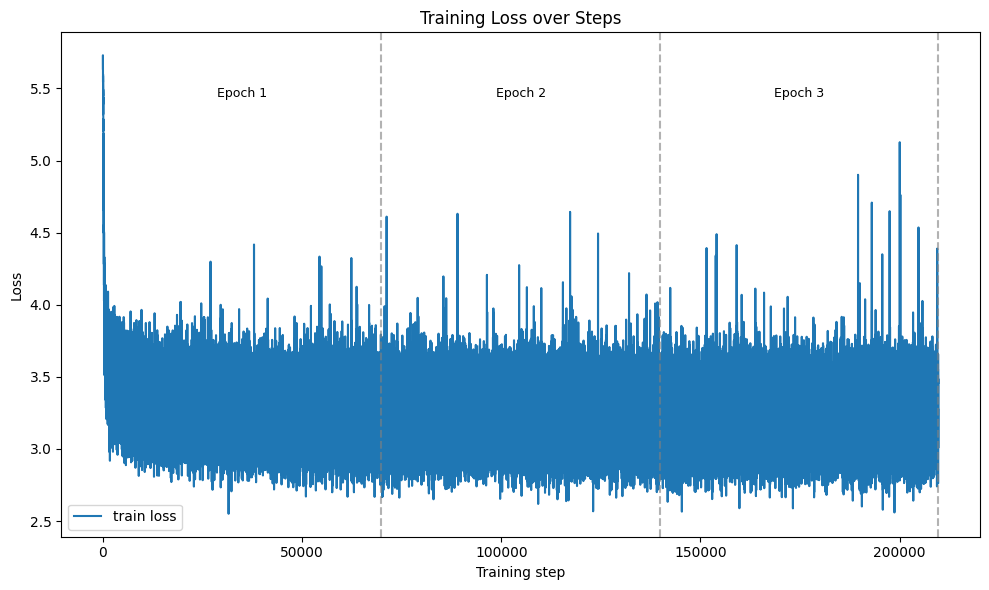

In [43]:
class NeuralNet(nn.Module):
    def __init__(self,input_size, hidden_size,num_classes):
        super(NeuralNet, self).__init__()
        self.l1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        return out

# ensure input_size matches prepared data
if 'X_train_t' in globals():
    input_size = X_train_t.shape[1]
else:
    # fallback to previously set value
    pass

model = NeuralNet(input_size, hidden_size, len(target_categories))
model.to(device)

# loss and optimiser (instantiate loss)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# track loss over steps and epoch boundaries
loss_history = []
epoch_boundary_steps = []
global_step = 0

# training loop
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
    model.train()
    for i, (data,labels) in enumerate(train_loader):
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # forward
        outputs = model(data)
        loss = criterion(outputs, labels)

        # backwards
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # record loss and step
        loss_history.append(loss.item())
        global_step += 1

        if (i+1) % 64 == 0:
            print(f'epoch {epoch+1}/{num_epochs}, step {i+1}/{n_total_steps}, loss={loss.item():.4f}')

    # mark epoch boundary after finishing epoch
    epoch_boundary_steps.append(global_step)

# test
model.eval()
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    for data, labels in test_loader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)
        outputs = model(data)

        # value, index
        _, predictions = torch.max(outputs,1)
        n_samples += labels.shape[0]
        n_correct += (predictions == labels).sum().item()

acc = 100 * n_correct / n_samples if n_samples > 0 else 0
print(f'accuracy = {acc:.2f}%')

# Plot loss over training steps with epoch markers
import matplotlib.pyplot as plt
if len(loss_history) > 0:
    plt.figure(figsize=(10,6))
    plt.plot(loss_history, label='train loss')
    # draw vertical lines for epoch boundaries
    for eb in epoch_boundary_steps:
        plt.axvline(eb, color='gray', linestyle='--', alpha=0.6)
    # annotate epoch numbers between boundaries
    start = 0
    for idx, eb in enumerate(epoch_boundary_steps):
        mid = (start + eb) / 2 if eb > start else start
        y_pos = max(loss_history) if len(loss_history)>0 else 0
        plt.text(mid, y_pos*0.95, f'Epoch {idx+1}', ha='center', fontsize=9, color='black')
        start = eb
    plt.xlabel('Training step')
    plt.ylabel('Loss')
    plt.title('Training Loss over Steps')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No loss history recorded; training loop may not have run.')